In [1]:
# Cell 1: Load data, GA results, and run XGBoost tuning for
#         Baseline + GA top-5 USING THE UPDATED TUNING FUNCTION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display

from scipy.stats import randint, uniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, recall_score
from xgboost import XGBClassifier  # RF 대신 XGBoost 사용
import shap

# ------------------------------------
# 1) Load train / test data
# ------------------------------------
X_train = pd.read_csv("../nz/Xtr_nz.csv")
X_test  = pd.read_csv("../nz/Xte_nz.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

y_np = y_train.to_numpy().ravel()
y_te = y_test.to_numpy().ravel()

# ------------------------------------
# 2) Load GA results (ga_best.npz)
# ------------------------------------
ga_npz = np.load("../data/ga_svm_13penalty.npz", allow_pickle=True)
print("\n[INFO] npz keys:", ga_npz.files)

top_scores = np.asarray(ga_npz["top_scores"], dtype=float)

# Build top_cols_all from npz
if "top_masks" in ga_npz.files:
    raw_masks = list(ga_npz["top_masks"])
    top_cols_all = [
        np.flatnonzero(np.asarray(m, dtype=bool)).astype(int)
        for m in raw_masks
    ]
else:
    raw_cols = list(ga_npz["top_cols"])
    top_cols_all = [np.asarray(c, dtype=int) for c in raw_cols]

n_feat_total = X_train.shape[1]
print(f"[INFO] Loaded {len(top_cols_all)} GA feature sets.")

# ------------------------------------
# 3) Define XGB_PARAM_DIST (XGBoost Specific)
# ------------------------------------
# XGBoost 성능 극대화를 위한 하이퍼파라미터 분포 설정
XGB_PARAM_DIST = {
    "n_estimators": randint(100, 800),
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": uniform(0.01, 0.2),      # [0.01, 0.21] 범위
    "subsample": uniform(0.6, 0.4),          # [0.6, 1.0] 범위
    "colsample_bytree": uniform(0.6, 0.4),   # 각 트리당 피처 비율
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 0.5),                # 분할을 위한 최소 손실 감소
    "scale_pos_weight": [1, 2, 5],           # 클래스 불균형 대응 (필요 시 조정)
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)
RANDOM_STATE  = 42

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

def tune_xgb_for_features(feature_idx, label):
    """
    XGBoost hyperparameter tuning on a given feature subset.
    """
    X_sub = X_train.iloc[:, feature_idx].to_numpy()

    # n_jobs=-1로 병렬 처리, tree_method='hist'는 대용량 데이터 시 속도 향상에 도움
    xgb_clf = XGBClassifier(
        random_state=2042, 
        n_jobs=-1, 
        verbosity=0,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    rs = RandomizedSearchCV(
        estimator=xgb_clf,
        param_distributions=XGB_PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_np)

    best_params = dict(rs.best_params_)
    
    # 튜닝 결과 출력
    print(f"[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

# ------------------------------------
# 4) Build feature_sets: Baseline + GA top-5
# ------------------------------------
N_TOP_GA = 5

sorted_idx = np.argsort(top_scores)[::-1]
top_idx    = sorted_idx[:N_TOP_GA]

feature_sets = []

# (0) Baseline
all_cols = np.arange(n_feat_total, dtype=int)
feature_sets.append({
    "name": "Baseline (ALL wrapper)",
    "cols": all_cols,
})

# (1) GA top-5
for rank, idx in enumerate(top_idx, 1):
    cols = np.asarray(top_cols_all[idx], dtype=int)
    feature_sets.append({
        "name": f"GA-{rank} (idx={idx})",
        "cols": cols,
        "ga_score": float(top_scores[idx]),
    })

print("\n[INFO] Feature sets to tune (Baseline + GA top-5):")
for fs in feature_sets:
    print(f"  {fs['name']}: d={len(fs['cols'])}")

# ------------------------------------
# 5) Run tuning for each feature set USING XGBOOST
# ------------------------------------
for fs in feature_sets:
    params, cv_auc = tune_xgb_for_features(fs["cols"], fs["name"])
    fs["best_params"] = params
    fs["cv_auc"]      = cv_auc

c:\Users\junse\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X_train: (82, 32)
X_test : (36, 32)
y_train: (82,)
y_test : (36,)

[INFO] npz keys: ['run_ids', 'top_scores', 'top_masks', 'top_cols']
[INFO] Loaded 5 GA feature sets.

[INFO] Feature sets to tune (Baseline + GA top-5):
  Baseline (ALL wrapper): d=32
  GA-1 (idx=0): d=14
  GA-2 (idx=1): d=13
  GA-3 (idx=2): d=13
  GA-4 (idx=3): d=13
  GA-5 (idx=4): d=13
[CV] Baseline (ALL wrapper) best AUC = 0.8661
[CV] Baseline (ALL wrapper) best params = {'colsample_bytree': np.float64(0.9073628244913841), 'gamma': np.float64(0.12083190064847465), 'learning_rate': np.float64(0.142094828457447), 'max_depth': 8, 'min_child_weight': 2, 'n_estimators': 135, 'scale_pos_weight': 5, 'subsample': np.float64(0.6764973434633089)}
[CV] GA-1 (idx=0) best AUC = 0.8209
[CV] GA-1 (idx=0) best params = {'colsample_bytree': np.float64(0.6488603152062401), 'gamma': np.float64(0.48690142932303027), 'learning_rate': np.float64(0.01699457312653318), 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 292, 'scale_pos_w

[Train CV ROC] Baseline (ALL wrapper): AUC 0.8724 ± 0.0897
[Train CV ROC] GA-1 (idx=0): AUC 0.8076 ± 0.0765
[Train CV ROC] GA-2 (idx=1): AUC 0.8403 ± 0.1028
[Train CV ROC] GA-3 (idx=2): AUC 0.8339 ± 0.0860
[Train CV ROC] GA-4 (idx=3): AUC 0.8870 ± 0.0594
[Train CV ROC] GA-5 (idx=4): AUC 0.8358 ± 0.0596


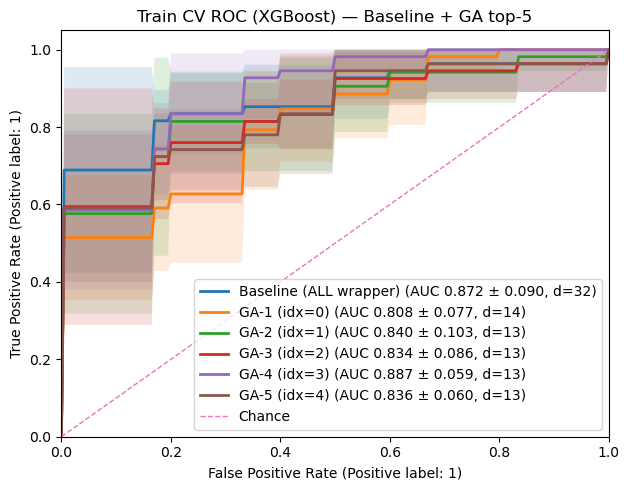

In [2]:
# Cell 2: Train CV ROC for Baseline + GA top-5
#         (NO NEW TUNING; use fs["best_params"] from Cell 1)

from xgboost import XGBClassifier

FPR_GRID = np.linspace(0.0, 1.0, 201)

def cv_roc_with_fixed_params(X, y, params, label, cv):
    """
    Given fixed XGBoost params, compute mean ± std ROC curves over the given CV object.
    """
    tprs = []
    aucs = []

    for tr_idx, va_idx in cv.split(X, y):
        # RandomForestClassifier -> XGBClassifier로 교체
        clf = XGBClassifier(
            random_state=2042,
            n_jobs=-1,
            verbosity=0,
            use_label_encoder=False,
            eval_metric='logloss',
            **params
        )
        
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[va_idx])[:, 1]

        fpr, tpr, _ = roc_curve(y[va_idx], prob)
        auc_fold = roc_auc_score(y[va_idx], prob)
        aucs.append(auc_fold)

        tpr_i = np.interp(FPR_GRID, fpr, tpr, left=0.0, right=1.0)
        tpr_i[0]  = 0.0
        tpr_i[-1] = 1.0
        tprs.append(tpr_i)

    tprs     = np.vstack(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr  = tprs.std(axis=0)
    auc_mean = float(np.mean(aucs))
    auc_std  = float(np.std(aucs))

    print(f"[Train CV ROC] {label}: AUC {auc_mean:.4f} ± {auc_std:.4f}")
    return mean_tpr, std_tpr, auc_mean, auc_std

plt.figure(figsize=(6.4, 5.0))

for fs in feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    # Cell 1에서 찾은 최적의 XGBoost 파라미터 사용
    params = dict(fs["best_params"])

    X_sub = X_train.iloc[:, cols].to_numpy()

    mean_tpr, std_tpr, auc_mean, auc_std = cv_roc_with_fixed_params(
        X_sub, y_np, params, fs["name"], cv5
    )

    fs["cv_auc_mean"] = auc_mean
    fs["cv_auc_std"]  = auc_std

    label = f"{fs['name']} (AUC {auc_mean:.3f} ± {auc_std:.3f}, d={len(cols)})"
    plt.plot(FPR_GRID, mean_tpr, lw=2, label=label)
    plt.fill_between(
        FPR_GRID,
        np.maximum(mean_tpr - std_tpr, 0.0),
        np.minimum(mean_tpr + std_tpr, 1.0),
        alpha=0.15,
    )

plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("Train CV ROC (XGBoost) — Baseline + GA top-5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [3]:
# Cell 3: Summary Statistics, Jaccard Stability, and Sensitivity for GA Subsets
#         (Using XGBoost from Cell 1 & 2)

from xgboost import XGBClassifier
from sklearn.metrics import recall_score

# ------------------------------------------------
# 1) Collect only GA-based feature sets (exclude Baseline)
# ------------------------------------------------
ga_feature_sets = [fs for fs in feature_sets if fs["name"].startswith("GA-")]

if len(ga_feature_sets) == 0:
    raise ValueError("No GA feature sets found. Make sure feature_sets contains entries named 'GA-1', 'GA-2', ...")

subset_names = [fs["name"] for fs in ga_feature_sets]
subset_sizes = [len(fs["cols"]) for fs in ga_feature_sets]
ga_auc_means = np.array([fs["cv_auc_mean"] for fs in ga_feature_sets], dtype=float)
ga_auc_stds  = np.array([fs["cv_auc_std"]  for fs in ga_feature_sets], dtype=float)

# --------------------------------------------
# Table 1: per-GA-subset CV AUC summary
# --------------------------------------------
auc_table = pd.DataFrame({
    "subset": subset_names,
    "n_features": subset_sizes,
    "cv_auc_mean_over_folds": ga_auc_means,
    "cv_auc_std_over_folds": ga_auc_stds,
})
auc_table = auc_table.sort_values("subset").reset_index(drop=True)

# Across-subset AUC stability:
auc_across_mean = float(ga_auc_means.mean())
auc_across_std  = float(ga_auc_means.std(ddof=1)) 

auc_stability_summary = pd.DataFrame({
    "metric": ["across_subsets_mean_AUC", "across_subsets_std_AUC"],
    "value":  [auc_across_mean,            auc_across_std]
})

# --------------------------------------------
# 2) Jaccard similarity between GA subsets
# --------------------------------------------
def jaccard_similarity(indices_a, indices_b):
    set_a = set(indices_a)
    set_b = set(indices_b)
    union = set_a | set_b
    if not union:
        return 0.0
    inter = set_a & set_b
    return len(inter) / len(union)

n_ga   = len(ga_feature_sets)
labels = [fs["name"] for fs in ga_feature_sets]

jacc_matrix = np.zeros((n_ga, n_ga), dtype=float)

for i in range(n_ga):
    for j in range(n_ga):
        jacc_matrix[i, j] = jaccard_similarity(
            ga_feature_sets[i]["cols"],
            ga_feature_sets[j]["cols"]
        )

jacc_df = pd.DataFrame(jacc_matrix, index=labels, columns=labels)

upper_vals = [
    jacc_matrix[i, j]
    for i in range(n_ga)
    for j in range(i + 1, n_ga)
]

jacc_mean = float(np.mean(upper_vals)) if upper_vals else 0.0
jacc_std  = float(np.std(upper_vals, ddof=1)) if len(upper_vals) > 1 else 0.0

jacc_summary = pd.DataFrame({
    "metric": ["mean_Jaccard_over_pairs", "std_Jaccard_over_pairs"],
    "value":  [jacc_mean,                  jacc_std]
})

# --------------------------------------------
# 3) Sensitivity comparison: mean recall at 0.5 (XGBoost)
# --------------------------------------------
def cv_sensitivity_at_threshold(X, y, params, cv, threshold=0.5):
    """
    Compute mean ± std sensitivity (recall) using XGBClassifier.
    """
    recalls = []

    for tr_idx, va_idx in cv.split(X, y):
        # RandomForestClassifier -> XGBClassifier
        clf = XGBClassifier(
            random_state=2042,
            n_jobs=-1,
            verbosity=0,
            use_label_encoder=False,
            eval_metric='logloss',
            **params
        )
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[va_idx])[:, 1]

        y_pred = (prob >= threshold).astype(int)
        rec = recall_score(y[va_idx], y_pred, pos_label=1)
        recalls.append(rec)

    recalls = np.array(recalls, dtype=float)
    return float(recalls.mean()), float(recalls.std(ddof=1))

sens_rows = []
for fs in ga_feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])
    X_sub  = X_train.iloc[:, cols].to_numpy()
    y_sub  = y_np

    sens_mean, sens_std = cv_sensitivity_at_threshold(
        X_sub, y_sub, params, cv5, threshold=0.5
    )

    sens_rows.append({
        "subset": fs["name"],
        "n_features": len(cols),
        "cv_auc_mean_over_folds": fs["cv_auc_mean"],
        "cv_auc_std_over_folds":  fs["cv_auc_std"],
        "sensitivity_mean_at_0.5": sens_mean,
        "sensitivity_std_at_0.5":  sens_std,
    })

sens_table = pd.DataFrame(sens_rows).sort_values("subset").reset_index(drop=True)

# --------------------------------------------
# 4) Display all tables
# --------------------------------------------
print("### Table: Per-GA-subset AUC Statistics (XGBoost)")
display(auc_table.round(3))
print("\n### Table: Across-subset AUC Stability")
display(auc_stability_summary.round(4))
print("\n### Table: Jaccard Similarity Matrix")
display(jacc_df.round(3))
print("\n### Table: Jaccard Stability Summary")
display(jacc_summary.round(4))
print("\n### Table: Final AUC + Sensitivity (Recall at 0.5)")
display(sens_table.round(3))

### Table: Per-GA-subset AUC Statistics (XGBoost)


,subset,n_features,cv_auc_mean_over_folds,cv_auc_std_over_folds
0,GA-1 (idx=0),14,0.808,0.077
1,GA-2 (idx=1),13,0.840,0.103
2,GA-3 (idx=2),13,0.834,0.086
3,GA-4 (idx=3),13,0.887,0.059
4,GA-5 (idx=4),13,0.836,0.060



### Table: Across-subset AUC Stability


,metric,value
0,across_subsets_mean_AUC,0.8409
1,across_subsets_std_AUC,0.0288



### Table: Jaccard Similarity Matrix


,GA-1 (idx=0),GA-2 (idx=1),GA-3 (idx=2),GA-4 (idx=3),GA-5 (idx=4)
GA-1 (idx=0),1.000,0.500,0.350,0.286,0.286
GA-2 (idx=1),0.500,1.000,0.368,0.368,0.368
GA-3 (idx=2),0.350,0.368,1.000,0.300,0.182
GA-4 (idx=3),0.286,0.368,0.300,1.000,0.368
GA-5 (idx=4),0.286,0.368,0.182,0.368,1.000



### Table: Jaccard Stability Summary


,metric,value
0,mean_Jaccard_over_pairs,0.3377
1,std_Jaccard_over_pairs,0.0826



### Table: Final AUC + Sensitivity (Recall at 0.5)


,subset,n_features,cv_auc_mean_over_folds,cv_auc_std_over_folds,sensitivity_mean_at_0.5,sensitivity_std_at_0.5
0,GA-1 (idx=0),14,0.808,0.077,0.964,0.050
1,GA-2 (idx=1),13,0.840,0.103,0.927,0.076
2,GA-3 (idx=2),13,0.834,0.086,0.927,0.100
3,GA-4 (idx=3),13,0.887,0.059,0.927,0.119
4,GA-5 (idx=4),13,0.836,0.060,0.909,0.091


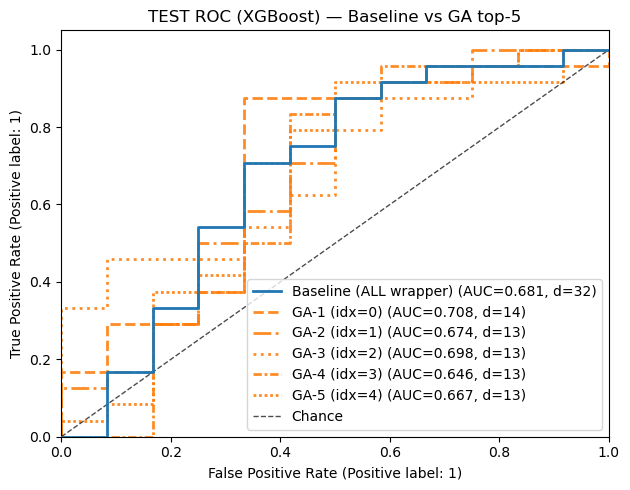


===== SUMMARY: Baseline + GA top-5 (CV & TEST with XGBoost) =====


,name,n_features,cv_auc_best,cv_auc_mean,cv_auc_std,test_auc
0,Baseline (ALL wrapper),32,0.8661,0.8724,0.0897,0.6806
1,GA-1 (idx=0),14,0.8209,0.8076,0.0765,0.7083
2,GA-2 (idx=1),13,0.8439,0.8403,0.1028,0.6736
3,GA-3 (idx=2),13,0.8336,0.8339,0.0860,0.6979
4,GA-4 (idx=3),13,0.8927,0.8870,0.0594,0.6458
5,GA-5 (idx=4),13,0.8415,0.8358,0.0596,0.6667


In [4]:
# Cell 4: Final train on FULL TRAIN + TEST ROC (Baseline + GA top-5)

from xgboost import XGBClassifier

plt.figure(figsize=(6.4, 5.0))

test_rows = []

# Colors: Baseline과 GA 서브셋을 구분하기 위한 색상 설정
COLOR_BASELINE = "tab:blue"   # Baseline용 색상
COLOR_GA       = "tab:orange" # GA 서브셋들을 위한 공통 색상

# GA-1 ~ GA-5를 구분하기 위한 선 스타일 (동일 색상, 다른 패턴)
GA_LINESTYLES = [
    "--",              # GA-1
    "-.",              # GA-2
    ":",               # GA-3
    (0, (3, 1, 1, 1)), # GA-4
    (0, (1, 1)),       # GA-5
]

ga_idx = 0

for fs in feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    # 데이터 준비
    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xte_sub = X_test.iloc[:,  cols].to_numpy()

    # XGBoost 모델 생성 및 학습
    clf = XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        use_label_encoder=False,
        eval_metric='logloss',
        **params
    )
    clf.fit(Xtr_sub, y_np)
    
    # 테스트 데이터 예측 확률
    prob_te = clf.predict_proba(Xte_sub)[:, 1]

    # ROC 및 AUC 계산
    auc_te = roc_auc_score(y_te, prob_te)
    fpr, tpr, _ = roc_curve(y_te, prob_te)

    # 시각화 스타일 설정 (Baseline vs GA)
    if fs["name"].lower().startswith("baseline"):
        curve_color = COLOR_BASELINE
        line_style  = "-"
        alpha       = 1.0
        z           = 3
    else:
        curve_color = COLOR_GA
        line_style  = GA_LINESTYLES[min(ga_idx, len(GA_LINESTYLES) - 1)]
        alpha       = 0.9
        z           = 2
        ga_idx += 1

    label = f"{fs['name']} (AUC={auc_te:.3f}, d={len(cols)})"

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=label,
        color=curve_color,
        linestyle=line_style,
        alpha=alpha,
        zorder=z,
    )

    test_rows.append({
        "name": fs["name"],
        "n_features": int(len(cols)),
        "cv_auc_mean": float(fs.get("cv_auc_mean", np.nan)),
        "cv_auc_std":  float(fs.get("cv_auc_std",  np.nan)),
        "cv_auc_best": float(fs.get("cv_auc", np.nan)),  # Tuning 단계 AUC
        "test_auc":    float(auc_te),
    })

# Chance line (랜덤 모델 기준선)
plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance", color="black", alpha=0.7)

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("TEST ROC (XGBoost) — Baseline vs GA top-5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 최종 결과 요약 테이블 출력
results_df = pd.DataFrame(test_rows)
print("\n===== SUMMARY: Baseline + GA top-5 (CV & TEST with XGBoost) =====")
display(results_df[["name", "n_features", "cv_auc_best", "cv_auc_mean", "cv_auc_std", "test_auc"]].round(4))

In [5]:
# Cell 5: Selection of the Representative GA Subset for SHAP (XGBoost based)

# 0) GA-only feature sets (exclude Baseline)
ga_feature_sets = [fs for fs in feature_sets if fs["name"].startswith("GA-")]
if len(ga_feature_sets) == 0:
    raise ValueError("No GA feature sets found in feature_sets (expected names starting with 'GA-').")

# 1) Lookup tables from auc_table / sens_table (from previous cell)
auc_lookup  = {row["subset"]: row for _, row in auc_table.iterrows()}
sens_lookup = {row["subset"]: row for _, row in sens_table.iterrows()}

# 2) Attach CV AUC / sensitivity stats into each GA feature set dict
for fs in ga_feature_sets:
    name = fs["name"]

    # CV AUC mean / std 데이터 매칭
    auc_row = auc_lookup.get(name, None)
    if auc_row is not None:
        fs["cv_auc_mean"] = float(auc_row["cv_auc_mean_over_folds"])
        fs["cv_auc_std"]  = float(auc_row["cv_auc_std_over_folds"])
    else:
        fs["cv_auc_mean"] = float("nan")
        fs["cv_auc_std"]  = float("nan")

    # Sensitivity mean / std (임계값 0.5) 데이터 매칭
    sens_row = sens_lookup.get(name, None)
    if sens_row is not None:
        fs["sensitivity_mean_at_0.5"] = float(sens_row["sensitivity_mean_at_0.5"])
        fs["sensitivity_std_at_0.5"]  = float(sens_row["sensitivity_std_at_0.5"])
    else:
        fs["sensitivity_mean_at_0.5"] = float("nan")
        fs["sensitivity_std_at_0.5"]  = float("nan")

# 3) Filter candidates by sensitivity >= 0.8 (민감도 기준 필터링)
SENS_MIN = 0.80
eligible = [
    fs for fs in ga_feature_sets
    if np.isfinite(fs.get("sensitivity_mean_at_0.5", np.nan))
    and fs["sensitivity_mean_at_0.5"] >= SENS_MIN
    and np.isfinite(fs.get("cv_auc_mean", np.nan))
]

if len(eligible) == 0:
    raise ValueError(f"No GA subsets meet sensitivity >= {SENS_MIN:.2f}. Consider lowering SENS_MIN or checking sens_table.")

# 4) Choose the subset whose CV AUC is closest to the median (중앙값 근접 후보 선정)
eligible_cv_means = np.array([fs["cv_auc_mean"] for fs in eligible], dtype=float)
target_median = float(np.median(eligible_cv_means))

# 1순위: 중앙값과의 차이 최소화 / 2순위: 낮은 표준편차 / 3순위: 더 적은 피처 수
best_ga = min(
    eligible,
    key=lambda fs: (
        abs(fs["cv_auc_mean"] - target_median),
        fs.get("cv_auc_std", np.inf),
        len(fs["cols"]),
    )
)

# 5) Summary Print
print(f"[INFO] Eligible GA candidates (sensitivity >= {SENS_MIN:.2f}):")
for fs in sorted(eligible, key=lambda x: x["cv_auc_mean"]):
    print(
        f"  {fs['name']}: d={len(fs['cols']):2d}, "
        f"CV AUC={fs['cv_auc_mean']:.4f} ± {fs.get('cv_auc_std', float('nan')):.4f}, "
        f"sens@0.5={fs['sensitivity_mean_at_0.5']:.4f}"
    )

print("-" * 50)
print(f"[INFO] Median CV AUC among eligible: {target_median:.4f}")
print("[INFO] Selected Best Subset for SHAP (XGBoost):")
print(f"  Name        : {best_ga['name']}")
print(f"  N Features  : {len(best_ga['cols'])}")
print(f"  CV AUC      : {best_ga['cv_auc_mean']:.4f} ± {best_ga.get('cv_auc_std', 0.0):.4f}")
print(f"  Sens@0.5    : {best_ga.get('sensitivity_mean_at_0.5', 0.0):.4f}")

[INFO] Eligible GA candidates (sensitivity >= 0.80):
  GA-1 (idx=0): d=14, CV AUC=0.8076 ± 0.0765, sens@0.5=0.9636
  GA-3 (idx=2): d=13, CV AUC=0.8339 ± 0.0860, sens@0.5=0.9273
  GA-5 (idx=4): d=13, CV AUC=0.8358 ± 0.0596, sens@0.5=0.9091
  GA-2 (idx=1): d=13, CV AUC=0.8403 ± 0.1028, sens@0.5=0.9273
  GA-4 (idx=3): d=13, CV AUC=0.8870 ± 0.0594, sens@0.5=0.9273
--------------------------------------------------
[INFO] Median CV AUC among eligible: 0.8358
[INFO] Selected Best Subset for SHAP (XGBoost):
  Name        : GA-5 (idx=4)
  N Features  : 13
  CV AUC      : 0.8358 ± 0.0596
  Sens@0.5    : 0.9091


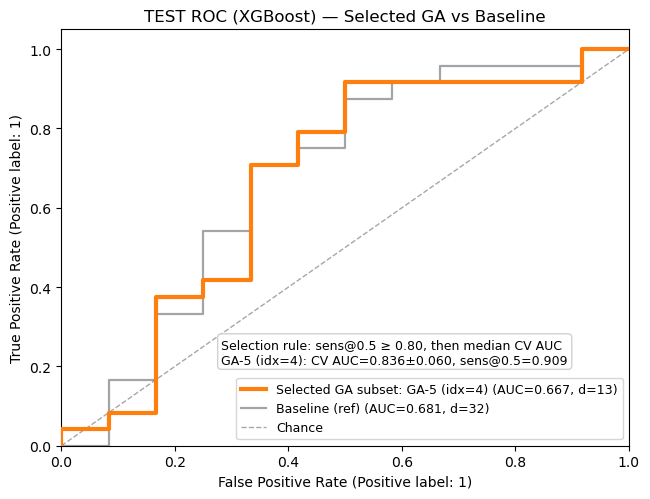


===== SUMMARY: Selected GA + Baseline (CV & TEST with XGBoost) =====


,name,n_features,cv_auc_best,cv_auc_mean,cv_auc_std,test_auc
0,GA-5 (idx=4),13,0.8415,0.8358,0.0596,0.6667
1,Baseline (ALL wrapper),32,0.8661,0.8724,0.0897,0.6806


In [6]:
# Cell: TEST ROC (Selected GA emphasized, Baseline as reference) - XGBoost Version

from xgboost import XGBClassifier

plt.figure(figsize=(6.6, 5.1))

test_rows_2 = []

# 1) Baseline 피처 세트 찾기
baseline_fs = None
for fs in feature_sets:
    if fs["name"].lower().startswith("baseline"):
        baseline_fs = fs
        break
if baseline_fs is None:
    raise ValueError("Baseline feature set not found in feature_sets.")

# 시각화 우선순위를 위해 GA 모델과 Baseline을 리스트에 담음
plot_sets = [best_ga, baseline_fs]

for fs in plot_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xte_sub = X_test.iloc[:,  cols].to_numpy()

    # RandomForestClassifier -> XGBClassifier로 교체
    clf = XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        use_label_encoder=False,
        eval_metric='logloss',
        **params
    )
    clf.fit(Xtr_sub, y_np)
    prob_te = clf.predict_proba(Xte_sub)[:, 1]

    auc_te = roc_auc_score(y_te, prob_te)
    fpr, tpr, _ = roc_curve(y_te, prob_te)

    is_baseline = (fs is baseline_fs)

    # 스타일 설정: GA 모델 강조, Baseline은 참고용으로 흐리게 처리
    if is_baseline:
        curve_color = "0.35"   # 회색
        line_style  = "-"
        alpha       = 0.55
        lw          = 1.6
        z           = 1
        label = f"Baseline (ref) (AUC={auc_te:.3f}, d={len(cols)})"
    else:
        curve_color = "tab:orange" # 강조 색상
        line_style  = "-"
        alpha       = 1.0
        lw          = 3.0
        z           = 3
        label = f"Selected GA subset: {fs['name']} (AUC={auc_te:.3f}, d={len(cols)})"

    plt.plot(
        fpr, tpr,
        lw=lw,
        label=label,
        color=curve_color,
        linestyle=line_style,
        alpha=alpha,
        zorder=z,
    )

    test_rows_2.append({
        "name": fs["name"],
        "n_features": int(len(cols)),
        "cv_auc_mean": float(fs.get("cv_auc_mean", np.nan)),
        "cv_auc_std":  float(fs.get("cv_auc_std",  np.nan)),
        "cv_auc_best": float(fs.get("cv_auc", np.nan)),
        "test_auc":    float(auc_te),
    })

# Chance line
plt.plot([0, 1], [0, 1], "--", lw=1, color="black", alpha=0.35, label="Chance")

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("TEST ROC (XGBoost) — Selected GA vs Baseline")

# 범례 표시 및 위치 설정
legend = plt.legend(loc="lower right", fontsize=9)

# 범례 위에 선정 규칙(Selection Rule) 텍스트 박스 추가
ax = plt.gca()
fig = plt.gcf()
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

bbox_disp = legend.get_window_extent(renderer=renderer)
bbox_ax   = bbox_disp.transformed(ax.transAxes.inverted())

x = bbox_ax.x0 + 0.05
y = bbox_ax.y1 + 0.02

ga_cv_mean = best_ga.get("cv_auc_mean", np.nan)
ga_cv_std  = best_ga.get("cv_auc_std", np.nan)
ga_sens    = best_ga.get("sensitivity_mean_at_0.5", np.nan)

note = (
    f"Selection rule: sens@0.5 ≥ {SENS_MIN:.2f}, then median CV AUC\n"
    f"{best_ga['name']}: CV AUC={ga_cv_mean:.3f}±{ga_cv_std:.3f}, sens@0.5={ga_sens:.3f}"
)

ax.text(
    x, y, note,
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9),
    clip_on=False
)

plt.tight_layout()
plt.show()

# 최종 결과 요약
results_df_2 = pd.DataFrame(test_rows_2)
print("\n===== SUMMARY: Selected GA + Baseline (CV & TEST with XGBoost) =====")
display(results_df_2[["name", "n_features", "cv_auc_best", "cv_auc_mean", "cv_auc_std", "test_auc"]].round(4))

In [7]:
import os
import numpy as np
import seaborn as sns
from xgboost import XGBClassifier

# ---------------------------------------------------------
# 1. 초기 설정: 폴더 및 논문용 스타일 (Serif 폰트)
# ---------------------------------------------------------
folder_path = "fig_gbm_mgmt"
os.makedirs(folder_path, exist_ok=True)

# 시각화 테마 설정
sns.set_theme(style="ticks", rc={"font.family": "serif"})
class_labels = ['Unmethylated', 'Methylated']

# ---------------------------------------------------------
# 2. 모델 예측값 생성 (XGBoost 버전)
# ---------------------------------------------------------

# A: Baseline 모델 (모든 피처 사용)
Xtr_all = X_train.to_numpy()
Xte_all = X_test.to_numpy()

# RandomForest -> XGBoost로 교체
clf_base = XGBClassifier(
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='logloss',
    **baseline_fs["best_params"]
)
clf_base.fit(Xtr_all, y_np)
y_pred_baseline = clf_base.predict(Xte_all)

# B: Best GA 모델 (선택된 d개 피처 사용)
cols_ga = np.asarray(best_ga["cols"], dtype=int)
Xtr_ga = X_train.iloc[:, cols_ga].to_numpy()
Xte_ga = X_test.iloc[:, cols_ga].to_numpy()

# RandomForest -> XGBoost로 교체
clf_ga = XGBClassifier(
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='logloss',
    **best_ga["best_params"]
)
clf_ga.fit(Xtr_ga, y_np)
y_pred_ga = clf_ga.predict(Xte_ga)

print(f"[INFO] Baseline 모델 학습 완료 (Features: {Xtr_all.shape[1]})")
print(f"[INFO] Selected GA 모델 학습 완료 (Features: {Xtr_ga.shape[1]})")

[INFO] Baseline 모델 학습 완료 (Features: 32)
[INFO] Selected GA 모델 학습 완료 (Features: 13)


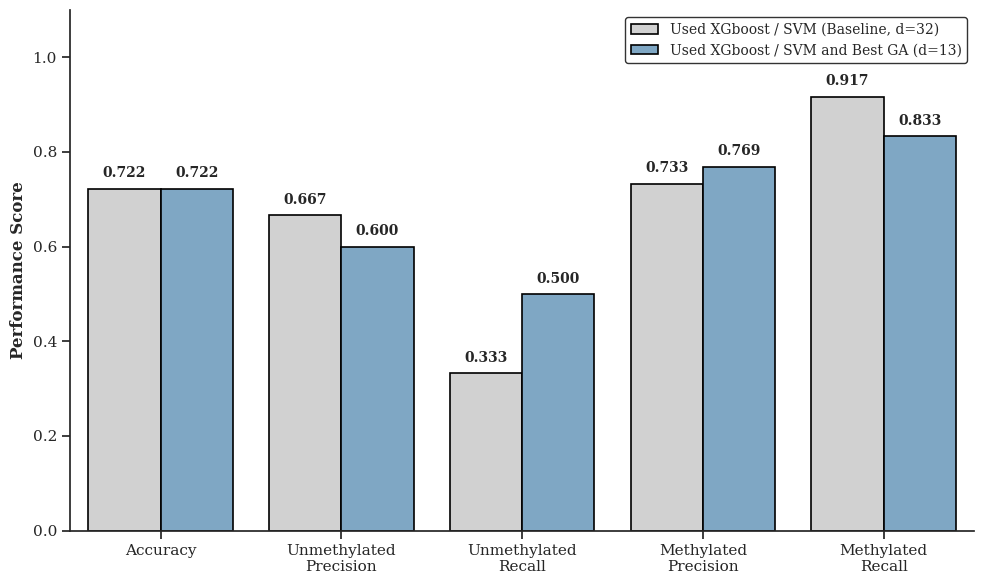

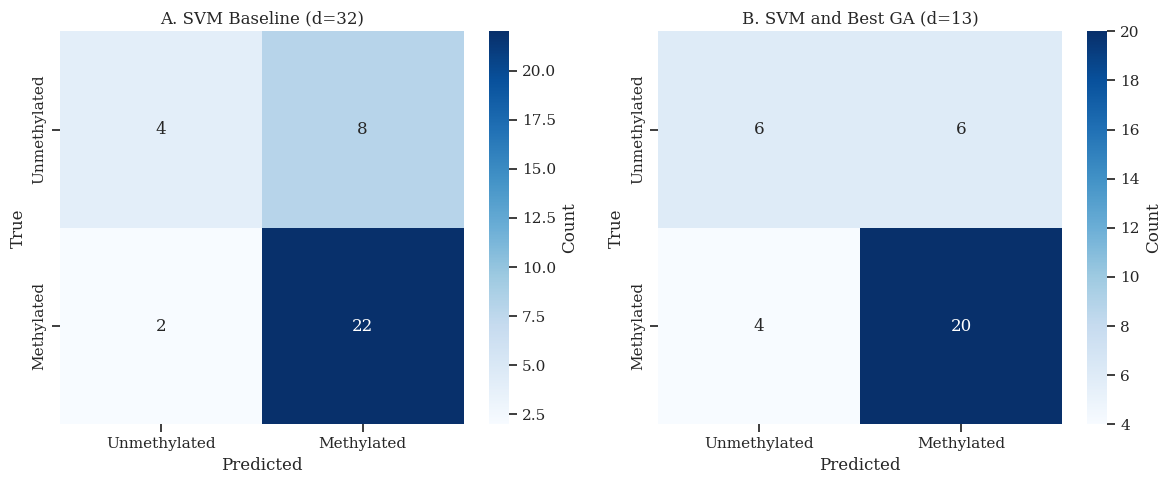

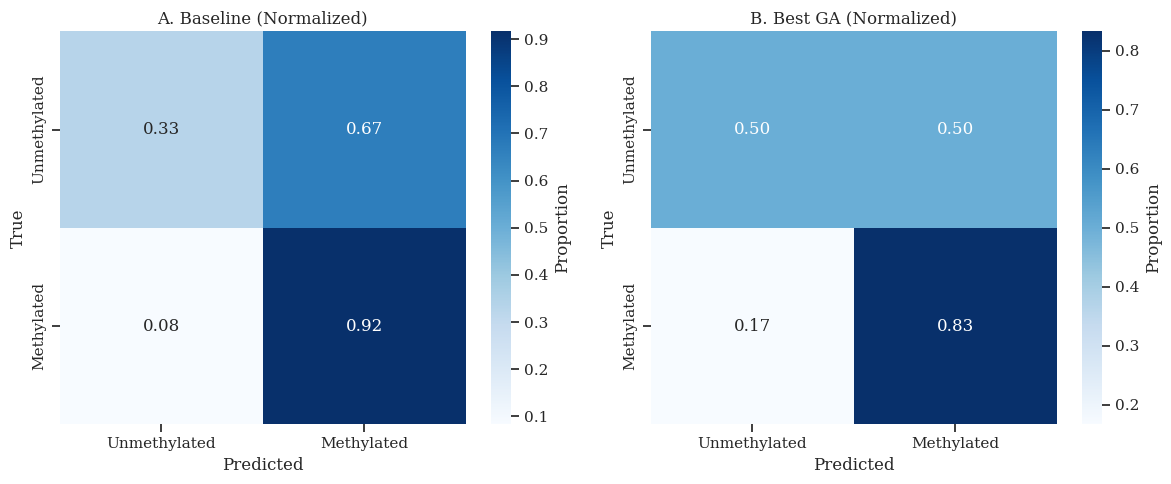

In [18]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix

# ---------------------------------------------------------
# 1. 초기 설정: 폴더 생성 및 스타일 적용
# ---------------------------------------------------------
folder_path = "fig_gbm_mgmt"
os.makedirs(folder_path, exist_ok=True)

# 폰트 오류 방지를 위한 rc 설정 (Serif 폰트 적용)
sns.set_theme(style="ticks", rc={"font.family": "serif"})
class_labels = ['Unmethylated', 'Methylated']

# 피처 개수 변수 설정 (그래프 라벨용)
d_baseline = X_train.shape[1]
d_best = len(best_ga["cols"])

# ---------------------------------------------------------
# 2. 성능 데이터 계산 및 구조화 (Bar Chart용)
# ---------------------------------------------------------
# 앞선 셀에서 생성한 y_pred_baseline과 y_pred_ga를 사용합니다.
metrics_data = {
    'Metric': [
        'Accuracy', 'Unmethylated\nPrecision', 'Unmethylated\nRecall', 
        'Methylated\nPrecision', 'Methylated\nRecall'
    ] * 2,
    'Score': [
        # XGBoost (Baseline)
        accuracy_score(y_test, y_pred_baseline), 
        precision_score(y_test, y_pred_baseline, average=None)[0],
        recall_score(y_test, y_pred_baseline, average=None)[0],
        precision_score(y_test, y_pred_baseline, average=None)[1],
        recall_score(y_test, y_pred_baseline, average=None)[1],
        # XGBoost with Best GA
        accuracy_score(y_test, y_pred_ga), 
        precision_score(y_test, y_pred_ga, average=None)[0],
        recall_score(y_test, y_pred_ga, average=None)[0],
        precision_score(y_test, y_pred_ga, average=None)[1],
        recall_score(y_test, y_pred_ga, average=None)[1]
    ],
    'Model': [f'Used XGboost / SVM (Baseline, d={d_baseline})'] * 5 + [f'Used XGboost / SVM and Best GA (d={d_best})'] * 5
}
df_metrics = pd.DataFrame(metrics_data)

# --- Metric Bar Chart 생성 및 저장 ---
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df_metrics, x='Metric', y='Score', hue='Model', 
    palette=['#d1d1d1', '#74a9cf'], edgecolor='black', linewidth=1.2
)

ax_bar.set_ylabel('Performance Score', fontsize=12, fontweight='bold')
ax_bar.set_xlabel('')
ax_bar.set_ylim(0, 1.1) # 점수 범위 조정
sns.despine()

# 막대 위에 수치 표시
for container in ax_bar.containers:
    ax_bar.bar_label(container, fmt='%.3f', padding=6, weight='bold', size=10)

plt.legend(frameon=True, loc='upper right', fontsize=10, edgecolor='black')
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "XGBoost_GA_Metrics.png"), dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. Confusion Matrix 계산 및 시각화
# ---------------------------------------------------------
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=[0, 1])
cm_best_ga = confusion_matrix(y_test, y_pred_ga, labels=[0, 1])

# 정규화 버전 생성
cm_baseline_norm = cm_baseline.astype('float') / cm_baseline.sum(axis=1)[:, np.newaxis]
cm_best_ga_norm = cm_best_ga.astype('float') / cm_best_ga.sum(axis=1)[:, np.newaxis]

# --- A: Count Confusion Matrix 저장 ---
fig_count, axes_count = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Count'}, ax=axes_count[0])
axes_count[0].set_title(f"A. SVM Baseline (d={d_baseline})")
axes_count[0].set_xlabel("Predicted")
axes_count[0].set_ylabel("True")

sns.heatmap(cm_best_ga, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Count'}, ax=axes_count[1])
axes_count[1].set_title(f"B. SVM and Best GA (d={d_best})")
axes_count[1].set_xlabel("Predicted")
axes_count[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "Confusion_Matrix_XGBoost_Count.png"), dpi=300)

# --- B: Normalized Confusion Matrix 저장 ---
fig_norm, axes_norm = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_baseline_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Proportion'}, ax=axes_norm[0])
axes_norm[0].set_title(f"A. Baseline (Normalized)")
axes_norm[0].set_xlabel("Predicted")
axes_norm[0].set_ylabel("True")

sns.heatmap(cm_best_ga_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Proportion'}, ax=axes_norm[1])
axes_norm[1].set_title(f"B. Best GA (Normalized)")
axes_norm[1].set_xlabel("Predicted")
axes_norm[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "Confusion_Matrix_XGBoost_Normalized.png"), dpi=300)

plt.show()

[INFO] SHAP values calculated using XGBoost Native Engine.
[INFO] Shape: (82, 13)


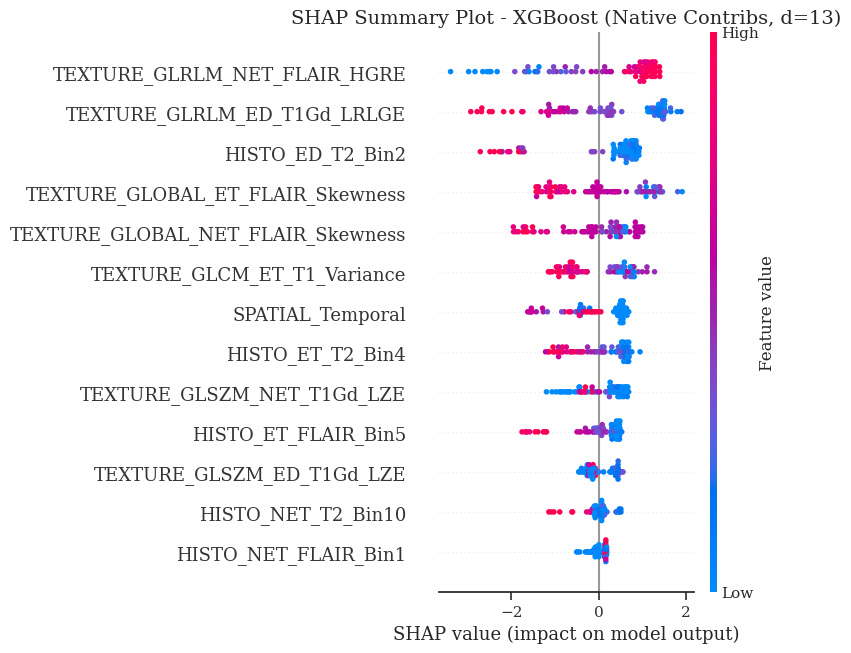

[INFO] SHAP summary plot saved to: fig_gbm_mgmt\XGBoost_GA_SHAP_Native_Fixed.png


In [12]:
# Cell: Final GA-XGBoost SHAP (Fixed: use xgboost.DMatrix)

import numpy as np
import shap
import matplotlib.pyplot as plt
import os
import xgboost as xgb  # xgboost를 직접 사용
from xgboost import XGBClassifier

RANDOM_STATE = 42

# ---------------------------------------------------------
# 1) GA-selected feature subset
# ---------------------------------------------------------
ga_cols   = np.asarray(best_ga["cols"], dtype=int)
ga_params = dict(best_ga["best_params"])

Xtr_ga = X_train.iloc[:, ga_cols]
y_tr   = y_train.to_numpy().ravel()

# ---------------------------------------------------------
# 2) Fit final XGBoost
# ---------------------------------------------------------
xgb_ga_shap = XGBClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='logloss',
    **ga_params
)
xgb_ga_shap.fit(Xtr_ga, y_tr)

# ---------------------------------------------------------
# 3) SHAP Values Calculation (XGBoost Native Engine)
# ---------------------------------------------------------
# SHAP 라이브러리의 파싱 에러를 피하기 위해 XGBoost 자체 기능을 사용합니다.
booster = xgb_ga_shap.get_booster()

# shap.DMatrix(X)가 아니라 xgb.DMatrix(X)를 사용해야 합니다.
dtrain = xgb.DMatrix(Xtr_ga)

# pred_contribs=True 옵션은 SHAP value와 동일한 값을 계산하여 반환합니다.
shap_values_native = booster.predict(dtrain, pred_contribs=True)

# XGBoost의 pred_contribs 결과: [샘플 수, 피처 수 + 1]
# 마지막 컬럼은 'Expected Value(Bias)'이므로 시각화를 위해 제거합니다.
if shap_values_native.shape[1] == Xtr_ga.shape[1] + 1:
    shap_values_to_plot = shap_values_native[:, :-1]
else:
    shap_values_to_plot = shap_values_native

print(f"[INFO] SHAP values calculated using XGBoost Native Engine.")
print(f"[INFO] Shape: {shap_values_to_plot.shape}")

# ---------------------------------------------------------
# 4) Summary plot 시각화
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.rcParams['font.family'] = 'serif'

# 시각화 함수에는 계산된 행렬과 원본 데이터를 전달합니다.
shap.summary_plot(
    shap_values_to_plot, 
    Xtr_ga, 
    feature_names=Xtr_ga.columns,
    plot_type="dot",
    show=False
)

plt.title(f"SHAP Summary Plot - XGBoost (Native Contribs, d={len(ga_cols)})", fontsize=14)
plt.tight_layout()

# 폴더 생성 및 저장
folder_path = "fig_gbm_mgmt"
os.makedirs(folder_path, exist_ok=True)
save_path = os.path.join(folder_path, "XGBoost_GA_SHAP_Native_Fixed.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"[INFO] SHAP summary plot saved to: {save_path}")

In [13]:
# Print the feature names used for SHAP (i.e., the GA-selected subset)
print(f"\n[INFO] SHAP features used (total={Xtr_ga.shape[1]}):")
for i, name in enumerate(Xtr_ga.columns, 1):
    print(f"{i:02d}. {name}")

# (Optional) Print as a single Python list for easy copy/paste
print("\n[INFO] Feature list:")
print(list(Xtr_ga.columns))



[INFO] SHAP features used (total=13):
01. HISTO_ET_T2_Bin4
02. HISTO_ED_T2_Bin2
03. HISTO_NET_T2_Bin10
04. HISTO_ET_FLAIR_Bin5
05. HISTO_NET_FLAIR_Bin1
06. SPATIAL_Temporal
07. TEXTURE_GLOBAL_ET_FLAIR_Skewness
08. TEXTURE_GLOBAL_NET_FLAIR_Skewness
09. TEXTURE_GLCM_ET_T1_Variance
10. TEXTURE_GLRLM_ED_T1Gd_LRLGE
11. TEXTURE_GLRLM_NET_FLAIR_HGRE
12. TEXTURE_GLSZM_ED_T1Gd_LZE
13. TEXTURE_GLSZM_NET_T1Gd_LZE

[INFO] Feature list:
['HISTO_ET_T2_Bin4', 'HISTO_ED_T2_Bin2', 'HISTO_NET_T2_Bin10', 'HISTO_ET_FLAIR_Bin5', 'HISTO_NET_FLAIR_Bin1', 'SPATIAL_Temporal', 'TEXTURE_GLOBAL_ET_FLAIR_Skewness', 'TEXTURE_GLOBAL_NET_FLAIR_Skewness', 'TEXTURE_GLCM_ET_T1_Variance', 'TEXTURE_GLRLM_ED_T1Gd_LRLGE', 'TEXTURE_GLRLM_NET_FLAIR_HGRE', 'TEXTURE_GLSZM_ED_T1Gd_LZE', 'TEXTURE_GLSZM_NET_T1Gd_LZE']


In [14]:
# Cell: build t-SNE embedding on GA-selected feature subset (train + test)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cell: build t-SNE embedding on GA-selected feature subset (train + test)

RANDOM_STATE = 42

# 1) Use GA-selected feature indices from best_ga
ga_cols = np.asarray(best_ga["cols"], dtype=int)

# 2) Subset train / test features using the same GA subset
Xtr_ga = X_train.iloc[:, ga_cols]
Xte_ga = X_test.iloc[:, ga_cols]

# 3) Stack train + test into a single matrix for a joint t-SNE embedding
X_all_ga = np.vstack([Xtr_ga.to_numpy(), Xte_ga.to_numpy()])

# y_np, y_te are assumed to be defined earlier as 1D numpy arrays
y_all = np.concatenate([y_np, y_te])

# Indicator for train vs test (for plotting)
split_label = np.array(["train"] * len(y_np) + ["test"] * len(y_te))

print("[INFO] X_all_ga shape:", X_all_ga.shape)
print("[INFO] y_all length:", len(y_all))

# 4) Standardize features before running t-SNE
scaler = StandardScaler()
X_all_ga_scaled = scaler.fit_transform(X_all_ga)

# 5) Run t-SNE in 2D on GA-selected features
tsne = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate="auto",
    init="random",
    n_iter=1000,
    random_state=RANDOM_STATE,
    verbose=1,
)
X_all_tsne = tsne.fit_transform(X_all_ga_scaled)

print("[INFO] t-SNE embedding shape:", X_all_tsne.shape)

# 6) Pack into a DataFrame for convenient plotting
tsne_df = pd.DataFrame({
    "tsne1": X_all_tsne[:, 0],
    "tsne2": X_all_tsne[:, 1],
    "label": y_all,
    "split": split_label,
})


[INFO] X_all_ga shape: (118, 13)
[INFO] y_all length: 118
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 118 samples in 0.000s...


c:\Users\junse\miniconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 118 samples in 0.200s...
[t-SNE] Computed conditional probabilities for sample 118 / 118
[t-SNE] Mean sigma: 1.457306
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.764767
[t-SNE] KL divergence after 1000 iterations: 0.640819
[INFO] t-SNE embedding shape: (118, 2)


[INFO] Majority-vote features: >= 3/5 GA subsets
[INFO] n_features = 10
[CV] GA-majority (k>=3/5) best AUC = 0.8467
[CV] GA-majority (k>=3/5) best params = {'colsample_bytree': np.float64(0.9073628244913841), 'gamma': np.float64(0.12083190064847465), 'learning_rate': np.float64(0.142094828457447), 'max_depth': 8, 'min_child_weight': 2, 'n_estimators': 135, 'scale_pos_weight': 5, 'subsample': np.float64(0.6764973434633089)}

===== TRAIN (5-fold CV, fixed tuned params) =====
Best CV AUC from tuning (rs.best_score_) : 0.8467
CV AUC (mean ± std)                     : 0.8188 ± 0.1296
CV Sensitivity@0.5 (mean ± std)         : 0.9273 ± 0.1185


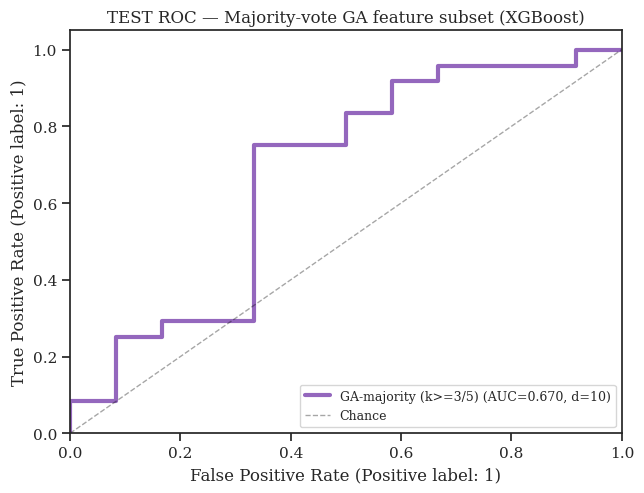


===== SUMMARY: Majority-vote GA subset (CV & TEST) =====
n_features  : 10
TEST AUC    : 0.6701


In [15]:
# Cell: Majority-vote (>=3 of 5 GA subsets) -> tune XGBoost -> train(CV) AUC/sensitivity -> test ROC

from xgboost import XGBClassifier

# -----------------------------
# 0) Majority-vote feature subset from GA top-5 (>=3/5)
# -----------------------------
ga5 = [fs for fs in feature_sets if fs["name"].startswith("GA-")]
if len(ga5) < 5:
    raise ValueError(f"Need 5 GA subsets in feature_sets. Found {len(ga5)}.")
ga5 = ga5[:5]

n_feat_total = X_train.shape[1]
cnt = np.zeros(n_feat_total, dtype=int)
for fs in ga5:
    cols = np.asarray(fs["cols"], dtype=int)
    cnt[cols] += 1

# 5개 중 3개 이상의 모델에서 선택된 피처만 추출
MAJ_K = 3
maj_cols = np.where(cnt >= MAJ_K)[0]
if len(maj_cols) == 0:
    raise ValueError(f"No features appear in >= {MAJ_K} of the 5 GA subsets.")

print(f"[INFO] Majority-vote features: >= {MAJ_K}/5 GA subsets")
print(f"[INFO] n_features = {len(maj_cols)}")

# -----------------------------
# 1) Tune XGBoost on TRAIN using existing tuning function
# -----------------------------
maj_label = f"GA-majority (k>={MAJ_K}/5)"
# 앞서 정의한 XGBoost용 튜닝 함수 호출
maj_best_params, maj_cv_best = tune_xgb_for_features(maj_cols, maj_label)

# -----------------------------
# 2) Train metrics via 5-fold CV (fixed best_params): AUC + sensitivity@0.5
# -----------------------------
Xtr = X_train.iloc[:, maj_cols].to_numpy()
ytr = y_np

auc_folds  = []
sens_folds = []

for tr_idx, va_idx in cv5.split(Xtr, ytr):
    X_tr_fold, X_va_fold = Xtr[tr_idx], Xtr[va_idx]
    y_tr_fold, y_va_fold = ytr[tr_idx], ytr[va_idx]

    # XGBClassifier 객체 생성
    clf = XGBClassifier(
        random_state=2026,
        n_jobs=-1,
        verbosity=0,
        use_label_encoder=False,
        eval_metric='logloss',
        **maj_best_params
    )
    clf.fit(X_tr_fold, y_tr_fold)

    prob_va = clf.predict_proba(X_va_fold)[:, 1]
    auc_va  = roc_auc_score(y_va_fold, prob_va)

    # 민감도(Sensitivity) 계산: 임계값 0.5 기준
    pred_va = (prob_va >= 0.5).astype(int)
    pos = (y_va_fold == 1)
    sens_va = ((pred_va == 1) & pos).sum() / max(pos.sum(), 1)

    auc_folds.append(auc_va)
    sens_folds.append(sens_va)

cv_auc_mean  = float(np.mean(auc_folds))
cv_auc_std   = float(np.std(auc_folds, ddof=1)) if len(auc_folds) > 1 else 0.0
cv_sens_mean = float(np.mean(sens_folds))
cv_sens_std  = float(np.std(sens_folds, ddof=1)) if len(sens_folds) > 1 else 0.0

print("\n===== TRAIN (5-fold CV, fixed tuned params) =====")
print(f"Best CV AUC from tuning (rs.best_score_) : {maj_cv_best:.4f}")
print(f"CV AUC (mean ± std)                     : {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")
print(f"CV Sensitivity@0.5 (mean ± std)         : {cv_sens_mean:.4f} ± {cv_sens_std:.4f}")

# -----------------------------
# 3) Fit on FULL TRAIN, evaluate on TEST, plot TEST ROC
# -----------------------------
Xte = X_test.iloc[:, maj_cols].to_numpy()

final_clf = XGBClassifier(
    random_state=2042,
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='logloss',
    **maj_best_params
)
final_clf.fit(Xtr, ytr)

prob_te = final_clf.predict_proba(Xte)[:, 1]
test_auc = float(roc_auc_score(y_te, prob_te))
fpr, tpr, _ = roc_curve(y_te, prob_te)

plt.figure(figsize=(6.6, 5.1))
plt.plot(
    fpr, tpr,
    lw=3.0,
    color="tab:purple", # 다수결 모델을 강조하기 위한 색상
    label=f"{maj_label} (AUC={test_auc:.3f}, d={len(maj_cols)})"
)
plt.plot([0, 1], [0, 1], "--", lw=1, color="black", alpha=0.35, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("TEST ROC — Majority-vote GA feature subset (XGBoost)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print("\n===== SUMMARY: Majority-vote GA subset (CV & TEST) =====")
print(f"n_features  : {len(maj_cols)}")
print(f"TEST AUC    : {test_auc:.4f}")

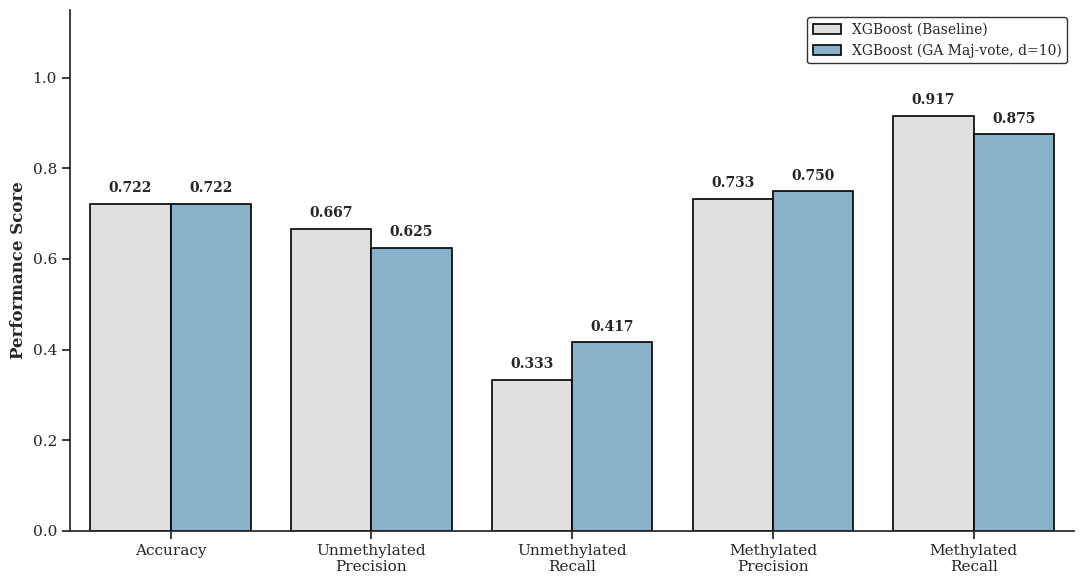

[INFO] Performance comparison chart saved as XGBoost_MajVote_Metrics.png


In [16]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, accuracy_score

# ---------------------------------------------------------
# 1. 스타일 및 폴더 설정
# ---------------------------------------------------------
sns.set_theme(style="ticks", rc={"font.family": "serif"})
folder_path = "fig_gbm_mgmt"
os.makedirs(folder_path, exist_ok=True)

# ---------------------------------------------------------
# 2. 데이터 준비 (final_clf 및 maj_cols 변수 사용)
# ---------------------------------------------------------
# 다수결 모델(final_clf)의 테스트 데이터 예측값 생성
y_pred_ga_maj = final_clf.predict(Xte)

metrics_data = {
    'Metric': ['Accuracy', 'Unmethylated\nPrecision', 'Unmethylated\nRecall', 
               'Methylated\nPrecision', 'Methylated\nRecall'] * 2,
    'Score': [
        # Baseline 모델 결과
        accuracy_score(y_test, y_pred_baseline), 
        precision_score(y_test, y_pred_baseline, average=None)[0],
        recall_score(y_test, y_pred_baseline, average=None)[0],
        precision_score(y_test, y_pred_baseline, average=None)[1],
        recall_score(y_test, y_pred_baseline, average=None)[1],
        # 다수결 GA 모델 결과
        accuracy_score(y_test, y_pred_ga_maj), 
        precision_score(y_test, y_pred_ga_maj, average=None)[0],
        recall_score(y_test, y_pred_ga_maj, average=None)[0],
        precision_score(y_test, y_pred_ga_maj, average=None)[1],
        recall_score(y_test, y_pred_ga_maj, average=None)[1]
    ],
    'Model': (['XGBoost (Baseline)'] * 5 + 
              [f'XGBoost (GA Maj-vote, d={len(maj_cols)})'] * 5)
}

df_metrics = pd.DataFrame(metrics_data)

# ---------------------------------------------------------
# 3. 그래프 생성
# ---------------------------------------------------------


fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', 
            palette=['#e0e0e0', '#7fb3d5'], edgecolor='black', linewidth=1.2)

ax.set_ylabel('Performance Score', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylim(0, 1.15)  # 수치 가독성을 위해 상단 여백 조정
sns.despine()

# 막대 상단에 스코어 라벨링
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=6, weight='bold', size=10)

plt.legend(frameon=True, loc='upper right', edgecolor='black', fontsize=10)
plt.tight_layout()

# ---------------------------------------------------------
# 4. 저장 및 출력
# ---------------------------------------------------------
save_filename = "XGBoost_MajVote_Metrics.png"
plt.savefig(os.path.join(folder_path, save_filename), dpi=300)
plt.show()

print(f"[INFO] Performance comparison chart saved as {save_filename}")

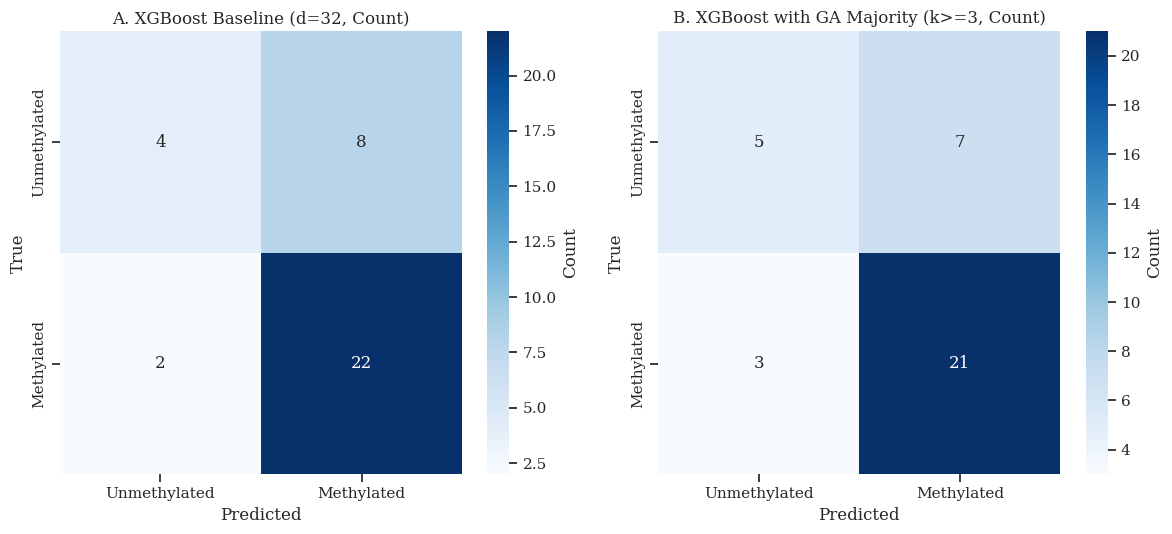

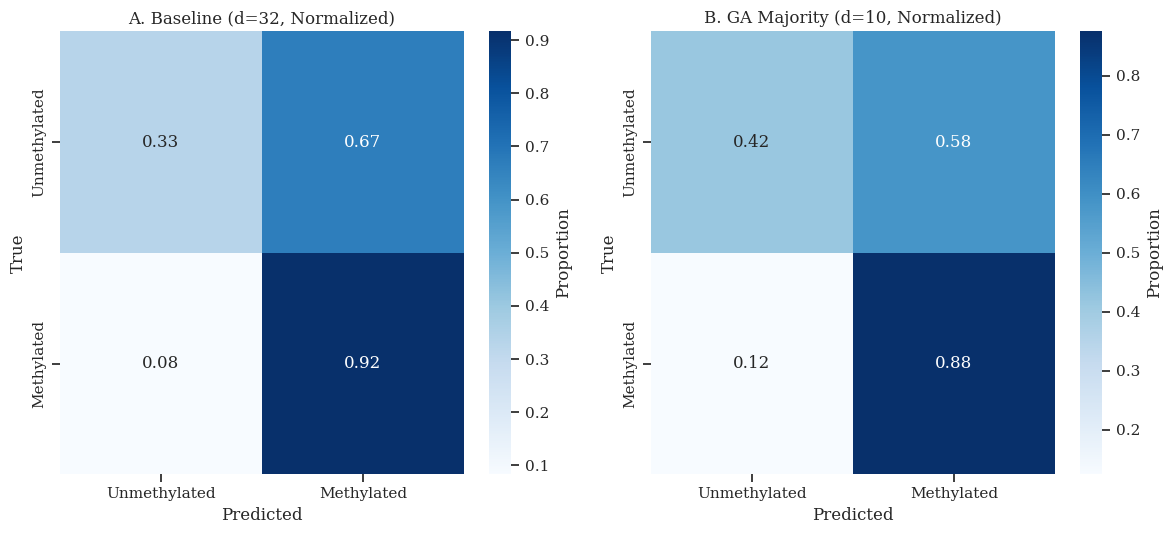

In [17]:
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 1. Confusion Matrix 계산 (XGBoost 결과 사용)
# ---------------------------------------------------------
class_labels = ['Unmethylated', 'Methylated']

# Baseline(전체 피처) vs Best GA Maj-vote(다수결 피처)
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=[0, 1])
cm_best_ga = confusion_matrix(y_test, y_pred_ga_maj, labels=[0, 1])

# 정규화 버전 생성 (비율 표시)
cm_baseline_normalized = cm_baseline.astype('float') / cm_baseline.sum(axis=1)[:, np.newaxis]
cm_best_ga_normalized = cm_best_ga.astype('float') / cm_best_ga.sum(axis=1)[:, np.newaxis]

# ---------------------------------------------------------
# 2. Count Confusion Matrix 시각화 (빈도수)
# ---------------------------------------------------------
fig_count, axes_count = plt.subplots(1, 2, figsize=(12, 5.5))

# Baseline - Count
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Count'}, ax=axes_count[0])
axes_count[0].set_title(f"A. XGBoost Baseline (d={X_train.shape[1]}, Count)")
axes_count[0].set_xlabel("Predicted")
axes_count[0].set_ylabel("True")

# Best GA Maj-vote - Count
sns.heatmap(cm_best_ga, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Count'}, ax=axes_count[1])
axes_count[1].set_title(f"B. XGBoost with GA Majority (k>={MAJ_K}, Count)")
axes_count[1].set_xlabel("Predicted")
axes_count[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "XGBoost_MajVote_CM_Count.png"), dpi=300)

# ---------------------------------------------------------
# 3. Normalized Confusion Matrix 시각화 (비율)
# ---------------------------------------------------------
fig_norm, axes_norm = plt.subplots(1, 2, figsize=(12, 5.5))

# Baseline - Normalized
sns.heatmap(cm_baseline_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Proportion'}, ax=axes_norm[0])
axes_norm[0].set_title(f"A. Baseline (d={X_train.shape[1]}, Normalized)")
axes_norm[0].set_xlabel("Predicted")
axes_norm[0].set_ylabel("True")

# Best GA Maj-vote - Normalized
sns.heatmap(cm_best_ga_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Proportion'}, ax=axes_norm[1])
axes_norm[1].set_title(f"B. GA Majority (d={len(maj_cols)}, Normalized)")
axes_norm[1].set_xlabel("Predicted")
axes_norm[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "XGBoost_MajVote_CM_Normalized.png"), dpi=300)
plt.show()

[INFO] Final RF trained for SHAP.
[INFO] Xtr_maj shape: (82, 10)
[INFO] shap_exp.values shape: (82, 10, 2)
[INFO] shap_exp.data   shape: (82, 10)


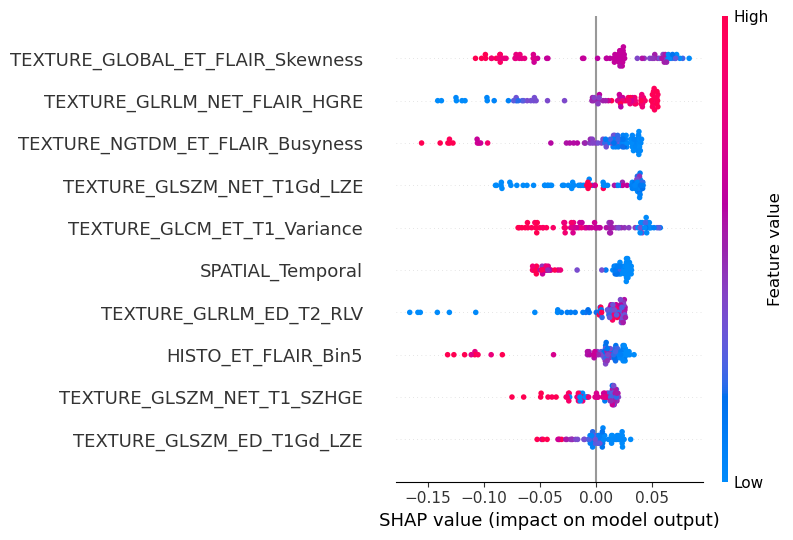

In [15]:
# Cell: SHAP for Majority-vote GA-RF (train only)

# 1) Use majority-vote feature subset + tuned params
maj_cols   = np.asarray(maj_cols, dtype=int)
maj_params = dict(maj_best_params)

Xtr_maj = X_train.iloc[:, maj_cols]
y_tr    = y_train.to_numpy().ravel()

# 2) Fit final RF on full TRAIN
rf_maj_shap = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_params
)
rf_maj_shap.fit(Xtr_maj, y_tr)

print("[INFO] Final RF trained for SHAP.")
print("[INFO] Xtr_maj shape:", Xtr_maj.shape)

# 3) SHAP explainer (tree-based)
explainer = shap.Explainer(
    rf_maj_shap,
    Xtr_maj,
    algorithm="tree",
)

# 4) Compute SHAP values on TRAIN
shap_exp = explainer(Xtr_maj)

vals = shap_exp.values
data = shap_exp.data

print("[INFO] shap_exp.values shape:", vals.shape)
print("[INFO] shap_exp.data   shape:", data.shape)

# 5) For binary RF: pick positive class along the last axis
if vals.ndim == 3:
    vals = vals[:, :, 1]

# 6) Summary plot (top 15)
shap.summary_plot(
    vals,
    data,
    feature_names=Xtr_maj.columns,
    max_display=15,
    show=True
)


In [16]:
# Get the feature names for the majority-vote subset
maj_feature_names = X_train.columns[maj_cols]

print(f"\n[INFO] SHAP features used (total={len(maj_feature_names)}):")
for i, name in enumerate(maj_feature_names, 1):
    print(f"{i:02d}. {name}")

# (Optional) Print as a single Python list for easy copy/paste
print("\n[INFO] Feature list:")
print(list(maj_feature_names))



[INFO] SHAP features used (total=10):
01. HISTO_ET_FLAIR_Bin5
02. SPATIAL_Temporal
03. TEXTURE_GLOBAL_ET_FLAIR_Skewness
04. TEXTURE_GLCM_ET_T1_Variance
05. TEXTURE_GLRLM_ED_T2_RLV
06. TEXTURE_GLRLM_NET_FLAIR_HGRE
07. TEXTURE_GLSZM_ED_T1Gd_LZE
08. TEXTURE_GLSZM_NET_T1Gd_LZE
09. TEXTURE_GLSZM_NET_T1_SZHGE
10. TEXTURE_NGTDM_ET_FLAIR_Busyness

[INFO] Feature list:
['HISTO_ET_FLAIR_Bin5', 'SPATIAL_Temporal', 'TEXTURE_GLOBAL_ET_FLAIR_Skewness', 'TEXTURE_GLCM_ET_T1_Variance', 'TEXTURE_GLRLM_ED_T2_RLV', 'TEXTURE_GLRLM_NET_FLAIR_HGRE', 'TEXTURE_GLSZM_ED_T1Gd_LZE', 'TEXTURE_GLSZM_NET_T1Gd_LZE', 'TEXTURE_GLSZM_NET_T1_SZHGE', 'TEXTURE_NGTDM_ET_FLAIR_Busyness']


Permutation importance identified a small set of features whose permutation caused the largest drop in training ROC AUC, suggesting these features contribute most strongly to the model’s predictive performance.


===== Permutation Importance (TRAIN, ROC AUC drop) =====


,feature,perm_importance_mean,perm_importance_std
5,TEXTURE_GLRLM_NET_FLAIR_HGRE,0.036574,0.011179
2,TEXTURE_GLOBAL_ET_FLAIR_Skewness,0.013591,0.009880
4,TEXTURE_GLRLM_ED_T2_RLV,0.010417,0.007509
9,TEXTURE_NGTDM_ET_FLAIR_Busyness,0.008102,0.009102
0,HISTO_ET_FLAIR_Bin5,0.006812,0.009344
6,TEXTURE_GLSZM_ED_T1Gd_LZE,0.006779,0.003226
7,TEXTURE_GLSZM_NET_T1Gd_LZE,0.006217,0.004995
8,TEXTURE_GLSZM_NET_T1_SZHGE,0.003042,0.003661
1,SPATIAL_Temporal,0.002315,0.006049
3,TEXTURE_GLCM_ET_T1_Variance,0.000198,0.005204


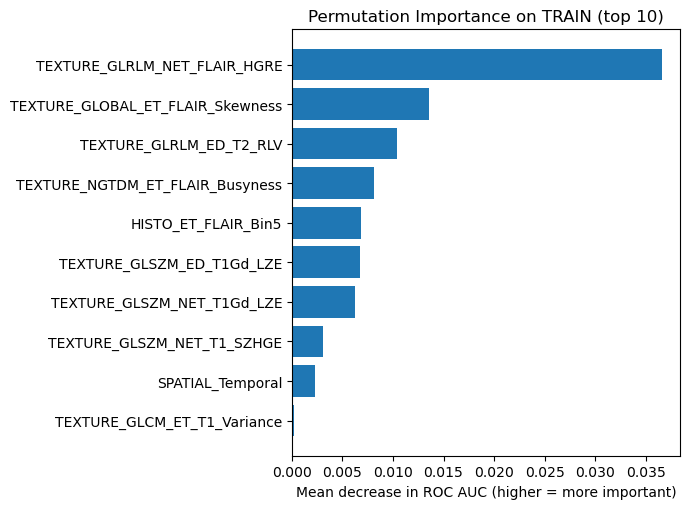

In [17]:
# Cell: Permutation Importance on TRAIN (ROC AUC drop) — use for interpretation

from sklearn.inspection import permutation_importance

# 0) Train final RF on FULL TRAIN (same params as evaluation)
Xtr_maj = X_train.iloc[:, maj_cols].to_numpy()
ytr     = y_np

rf = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_best_params
)
rf.fit(Xtr_maj, ytr)

feat_names = X_train.columns[maj_cols]

# 1) Permutation importance on TRAIN (AUC drop)
perm = permutation_importance(
    rf,
    Xtr_maj, ytr,
    scoring="roc_auc",
    n_repeats=20,
    random_state=2042,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": feat_names,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std":  perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

print("\n===== Permutation Importance (TRAIN, ROC AUC drop) =====")
display(imp_df.head(15))

topk = 10
plot_df = imp_df.head(topk).iloc[::-1]
plt.figure(figsize=(7.0, 5.2))
plt.barh(plot_df["feature"], plot_df["perm_importance_mean"])
plt.xlabel("Mean decrease in ROC AUC (higher = more important)")
plt.title(f"Permutation Importance on TRAIN (top {topk})")
plt.tight_layout()
plt.show()


In [18]:
# Cell: Report baseline TRAIN/TEST AUC + show AUC after permuting top features (TRAIN + TEST)

rng = np.random.default_rng(2042)

# 0) Baseline AUC on TRAIN and TEST (using the same trained rf)
prob_tr = rf.predict_proba(Xtr_maj)[:, 1]
train_auc = float(roc_auc_score(ytr, prob_tr))

Xte_maj = X_test.iloc[:, maj_cols].to_numpy()
prob_te = rf.predict_proba(Xte_maj)[:, 1]
test_auc = float(roc_auc_score(y_te, prob_te))

print("\n===== Baseline performance (same fitted model) =====")
print(f"TRAIN AUC: {train_auc:.4f}")
print(f"TEST  AUC: {test_auc:.4f}")

# 1) AUC after permuting each top feature once (single run) on TRAIN and TEST
TOPM = 5
top_features = imp_df["feature"].head(TOPM).tolist()
name_to_j = {name: j for j, name in enumerate(feat_names)}

print(f"\n===== AUC after permuting top {TOPM} features on TRAIN (single shuffle each) =====")
for name in top_features:
    j = name_to_j[name]

    Xtr_perm = Xtr_maj.copy()
    Xtr_perm[:, j] = np.random.permutation(Xtr_perm[:, j])

    prob_perm = rf.predict_proba(Xtr_perm)[:, 1]
    auc_perm  = float(roc_auc_score(ytr, prob_perm))

    print(f"{name}: TRAIN AUC {auc_perm:.4f}  (drop {train_auc - auc_perm:+.4f})")

print(f"\n===== AUC after permuting top {TOPM} features on TEST (single shuffle each) =====")
for name in top_features:
    j = name_to_j[name]

    Xte_perm = Xte_maj.copy()
    Xte_perm[:, j] = np.random.permutation(Xte_perm[:, j])

    prob_perm = rf.predict_proba(Xte_perm)[:, 1]
    auc_perm  = float(roc_auc_score(y_te, prob_perm))

    print(f"{name}: TEST  AUC {auc_perm:.4f}  (drop {test_auc - auc_perm:+.4f})")



===== Baseline performance (same fitted model) =====
TRAIN AUC: 0.9676
TEST  AUC: 0.7292

===== AUC after permuting top 5 features on TRAIN (single shuffle each) =====
TEXTURE_GLRLM_NET_FLAIR_HGRE: TRAIN AUC 0.9444  (drop +0.0231)
TEXTURE_GLOBAL_ET_FLAIR_Skewness: TRAIN AUC 0.9484  (drop +0.0192)
TEXTURE_GLRLM_ED_T2_RLV: TRAIN AUC 0.9663  (drop +0.0013)
TEXTURE_NGTDM_ET_FLAIR_Busyness: TRAIN AUC 0.9597  (drop +0.0079)
HISTO_ET_FLAIR_Bin5: TRAIN AUC 0.9583  (drop +0.0093)

===== AUC after permuting top 5 features on TEST (single shuffle each) =====
TEXTURE_GLRLM_NET_FLAIR_HGRE: TEST  AUC 0.7188  (drop +0.0104)
TEXTURE_GLOBAL_ET_FLAIR_Skewness: TEST  AUC 0.7083  (drop +0.0208)
TEXTURE_GLRLM_ED_T2_RLV: TEST  AUC 0.6528  (drop +0.0764)
TEXTURE_NGTDM_ET_FLAIR_Busyness: TEST  AUC 0.7292  (drop +0.0000)
HISTO_ET_FLAIR_Bin5: TEST  AUC 0.6771  (drop +0.0521)
